In [1]:
import sys
sys.path.append("/Users/sophia/Desktop/Fundamentals_of_Bioinformatics/BioInfoFinalProject")

In [2]:
import matplotlib.pyplot as plt
from trajectory_inference.Laplacian_Eigenmaps import loadAndCSR, laplacianEigenmaps, pseudotime
from data.preprocess.preprocess import adata

AnnData object with n_obs × n_vars = 1029 × 2000
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
PCA shape: (1029, 50)
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Embedding shape (1029, 2)
Pseudotime range -3.1365501476558704 3.134970649107792
Eigenvalues: [0.07382296 0.10627053]


In [10]:
# want k values that generate small eigenvalues close in value (ratio ~ 1)

kVals = list(range(10, 55, 5))

for k in kVals:
    csr = loadAndCSR(adata, k = k)
    emb, ev = laplacianEigenmaps(csr)
    evRatio = ev[1] / ev[0]
    print(f"k = {k}, eigenvals = {ev}, eigenval ratio = {evRatio}")

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 10, eigenvals = [0.06167295 0.08831302], eigenval ratio = 1.4319570875567895
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 15, eigenvals = [0.07382296 0.10627053], eigenval ratio = 1.4395321310279232
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 20, eigenvals = [0.0829407  0.12016102], eigenval ratio = 1.4487582158705057
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 25, eigenvals = [0.01038307 0.0932026 ], eigenval ratio = 8.976402205757683
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 30, eigenvals = [0.10222185 0.14956716], eigenval ratio = 1.4631622800581487
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 35, eigenvals = [0.01148142 0.10960882], eigenval ratio = 9.546626784292725
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
k = 40, eige

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


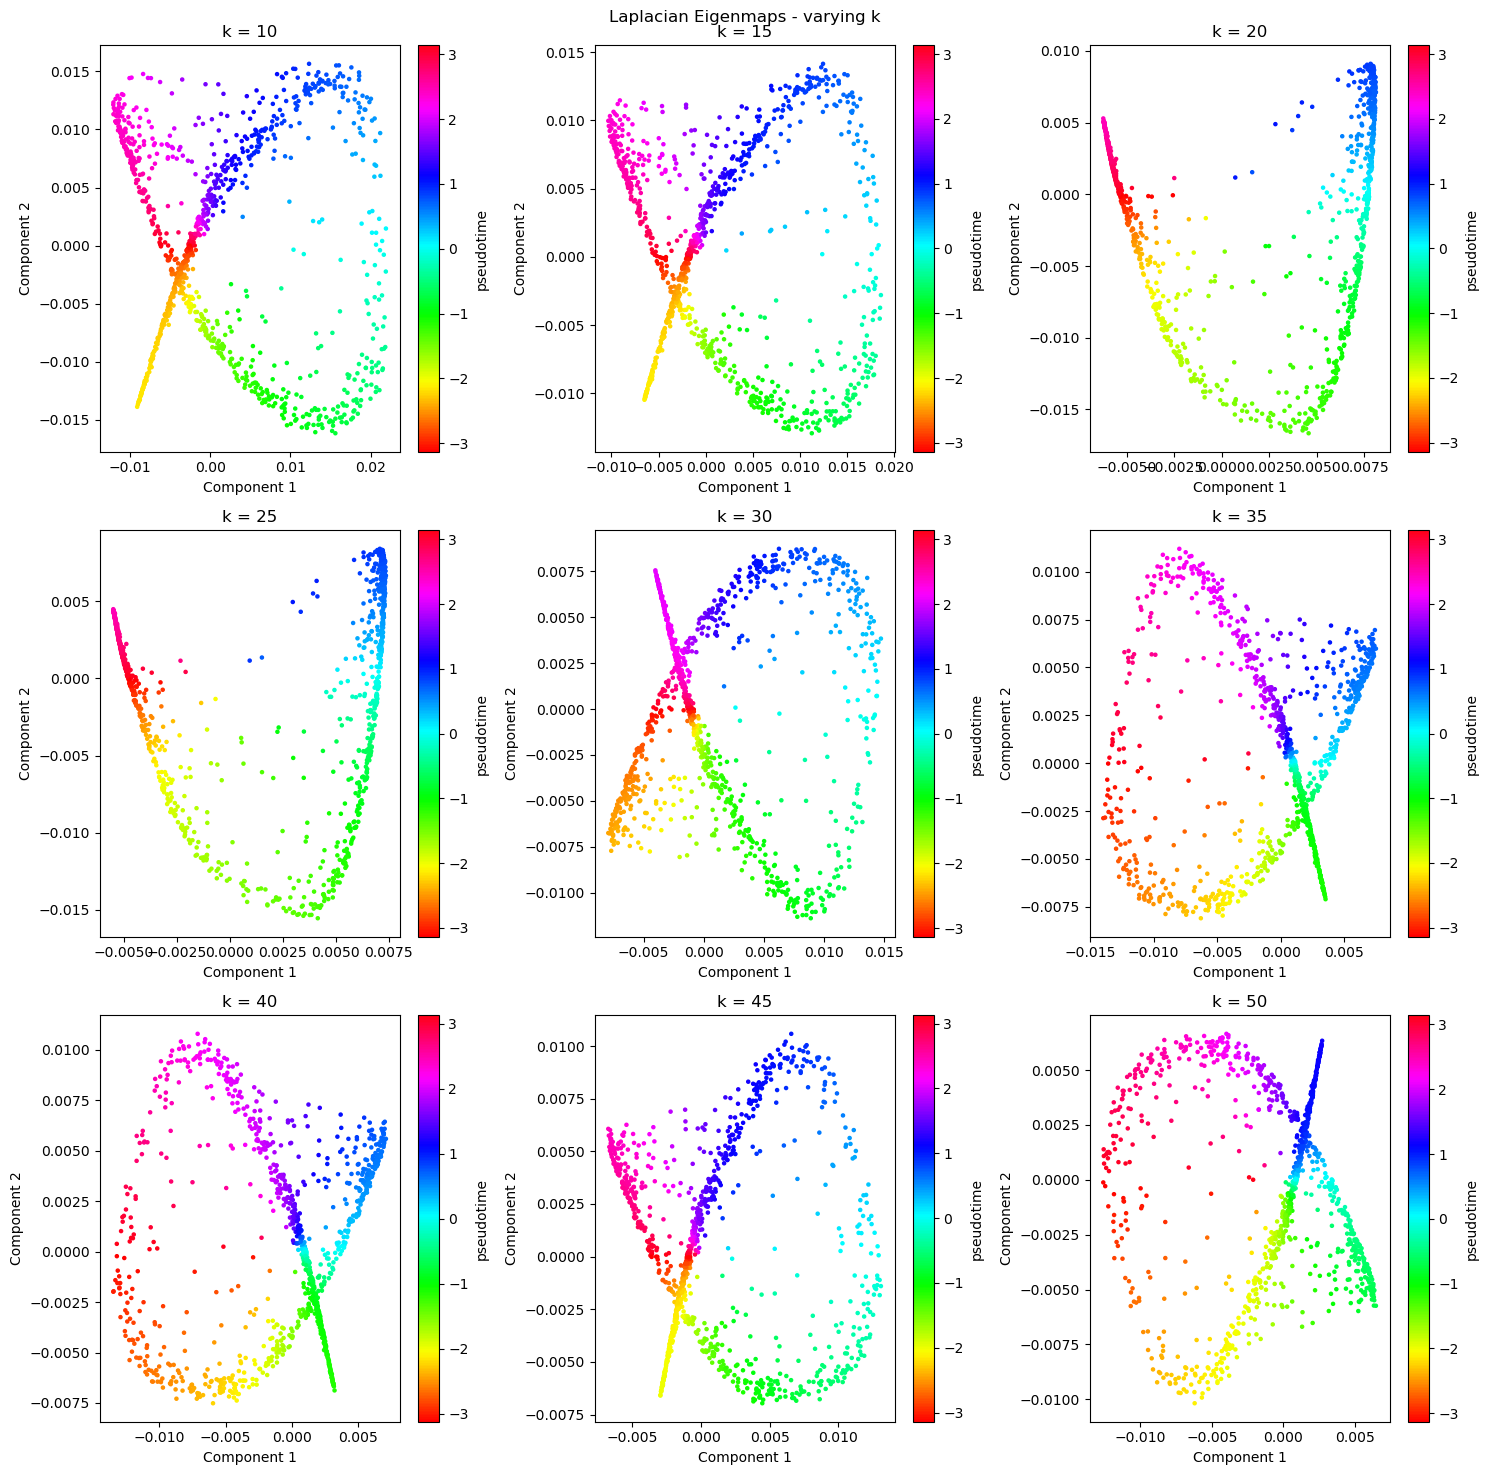

In [11]:
# checking plots with varying k clusters in kNN

kVals = list(range(10, 55, 5))
fig, axes = plt.subplots(3, 3, figsize = (15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    csr = loadAndCSR(adata, k = k)
    embeddings, eigvals = laplacianEigenmaps(csr)
    ps = pseudotime(embeddings)
    sc = axes[i].scatter(embeddings[:, 0], embeddings[:, 1], c = ps, cmap = "hsv", s = 5)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")
    plt.colorbar(sc, ax = axes[i], label = "pseudotime")

plt.suptitle("Laplacian Eigenmaps - varying k")
plt.tight_layout()
plt.show()

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


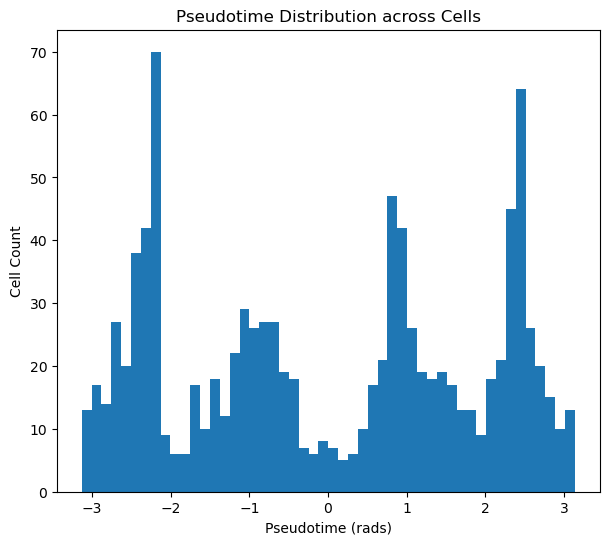

In [13]:
# plot of pseudotime distribution
csr = loadAndCSR(adata, k = 10)
embedding, eigvals = laplacianEigenmaps(csr)
pseudo = pseudotime(embedding)

plt.figure(figsize = (7, 6))
plt.hist(pseudo, bins = 50)
plt.xlabel("Pseudotime (rads)")
plt.ylabel("Cell Count")
plt.title("Pseudotime Distribution across Cells")
plt.show()